In [1]:
import sys
print(sys.executable)

c:\Credit-Card-Fraud-Detection\.venv\Scripts\python.exe


Title and Objective

# Credit Card Fraud Detection - Exploratory Data Analysis

## Objective
The goal of this project is to analyze transaction data and understand patterns that distinguish fraudulent from legitimate ones.

This notebook focuses on:
- Data understanding 
- Distribution analysis
- Fraud pattern detection
- Feature relationships


In [2]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
## Load Dataset

df = pd.read_csv("../data/raw/credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
##Basic Data Overview

df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

### Missing Value Analysis

The dataset contains no missing values across all features.

This means:
- No imputation techniques are required.
- Data preprocessing becomes simpler.
- The dataset is clean and ready for modeling.

### Data Type Analysis

The dataset contains:
- Numerical features (int64, float64) such as:
  - amount
  - transaction_hour
  - device_trust_score
- Categorical feature:
  - merchant_category (object type)
- Target variable:
  - is_fraud (binary: 0 or 1)

Since machine learning models require numerical inputs,
the categorical feature 'merchant_category' will need encoding.

### Class Imbalance Analysis

The dataset is highly imbalanced:

- Non-Fraud (0): 98%
- Fraud (1): 2%

This imbalance is common in fraud detection problems.

Implications:
- Accuracy alone is not a good metric.
- The model may bias toward predicting non-fraud.
- Special techniques like SMOTE or class weighting are required.
- Evaluation should focus on Recall, Precision, and ROC-AUC rather than accuracy.


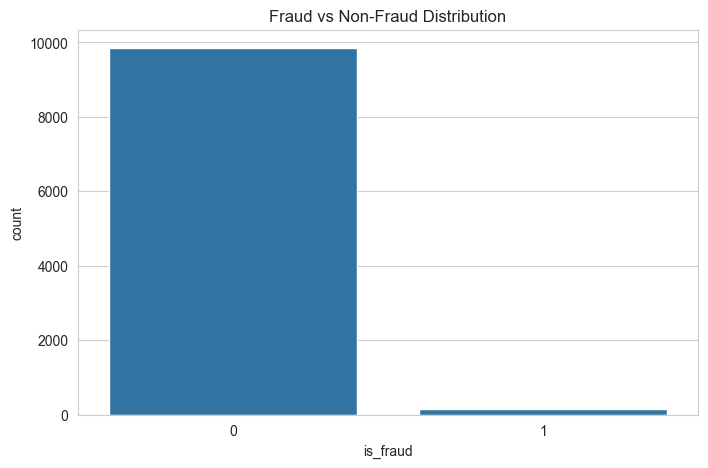

In [5]:
## Target Variable Analysis 

df['is_fraud'].value_counts()

sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


## Target Variable Analysis 

Dataset is highly imbalanced. So we need to use SMOTE to balance the data, to perform more on predicting with ROC - AUC, Recall,  and Precision rather than just accuracy dependence.

For improving the performance of the detection system we can add a more advanced version of SMOTE i.e; ADASYN, which also creates synthetic minority data samples to balance the dataset.

But the key differenc is that it is more concentrated on difficult circumstances to predict more precisely when comming across real-world samples.

## Fraud pecentage calculation
fraud_percentage = df['is_fraud'].mean() * 100
fraud_percentage

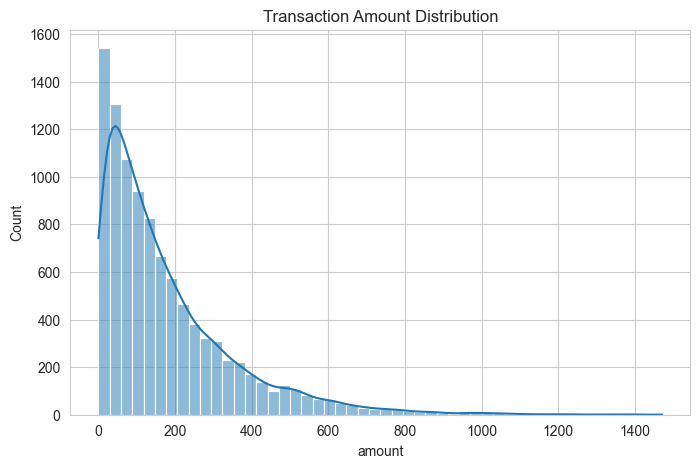

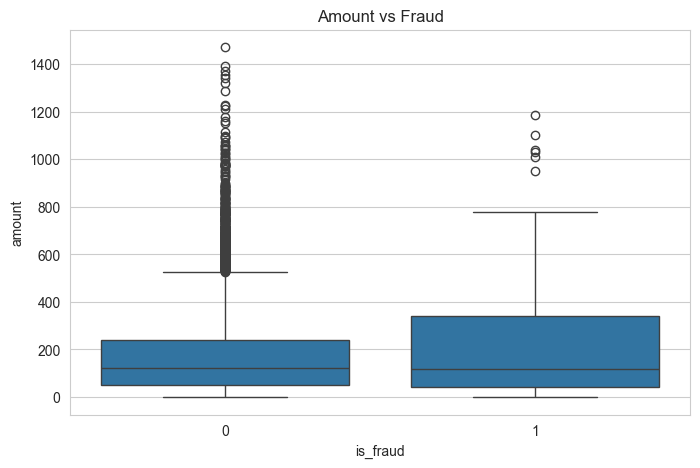

In [6]:
## Numerical Distribution

# Amount Distribution 

sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

# Compared Fraud vs Non-Fraud Amount

sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

## Are fraud transactions larger?

Since i observed on the analysis that with the dataset i used the fraud transactions are only upto 2% approx remaining 98% is legitimate.

But in real-time transactions it can be spread and even larger.

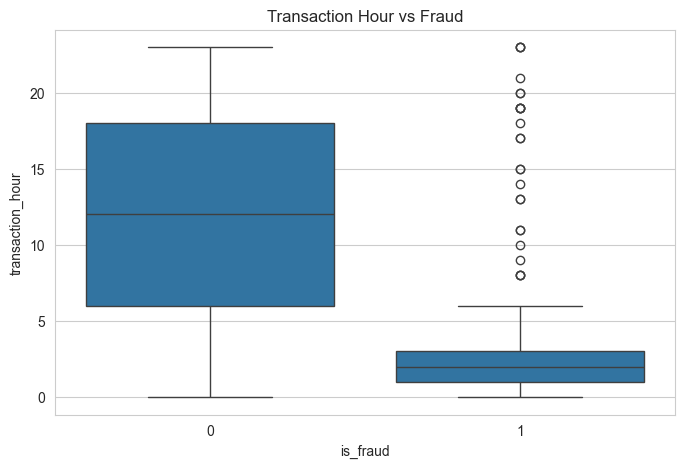

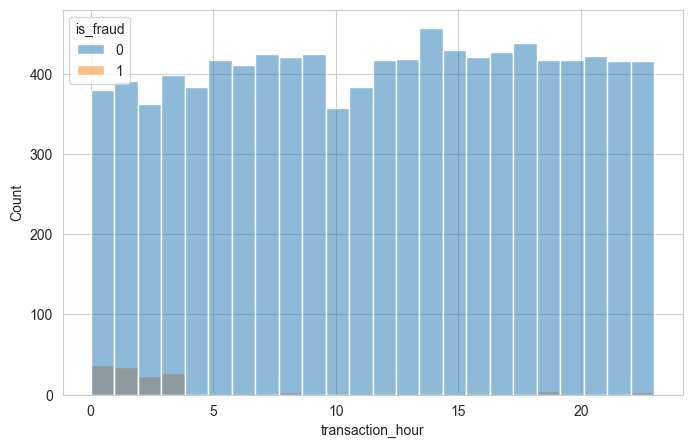

In [7]:
## Time-Based Analysis

sns.boxplot(x='is_fraud', y='transaction_hour', data=df)
plt.title("Transaction Hour vs Fraud")
plt.show()

sns.histplot(data=df, x='transaction_hour', hue='is_fraud', bins=24)
plt.show()

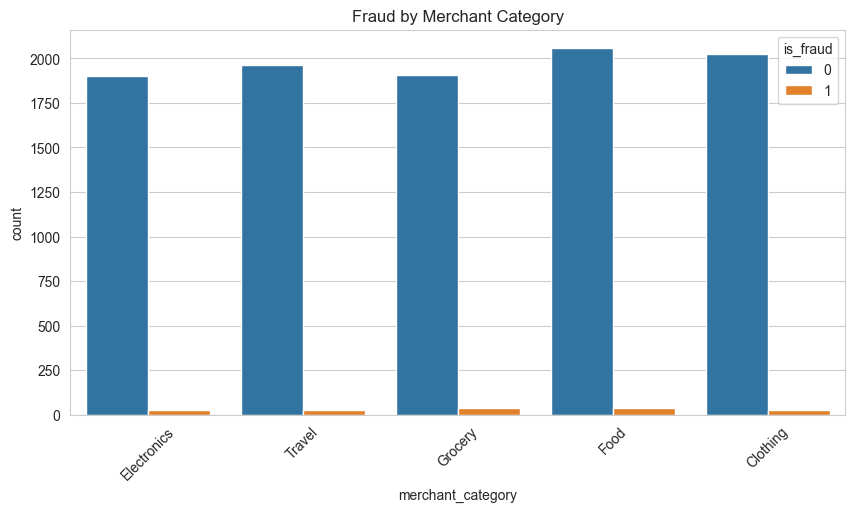

In [8]:
## Categorical Feature Analysis

# Assuming 'merchant_category' is a categorical feature

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='merchant_category', hue='is_fraud')
plt.xticks(rotation=45)
plt.title("Fraud by Merchant Category")
plt.show()

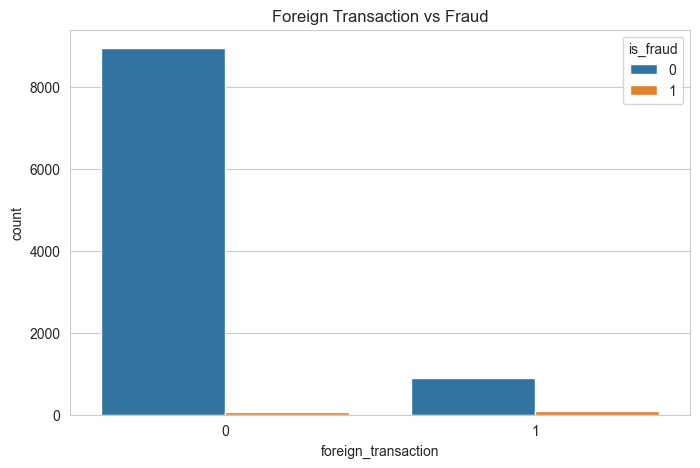

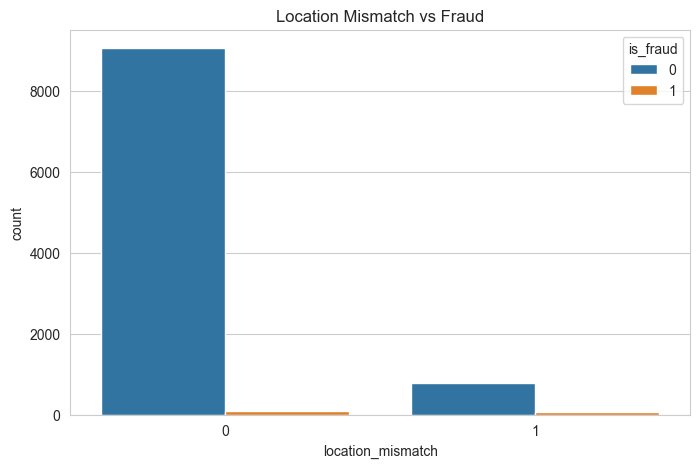

In [9]:
## Binary Feature Analysis

# Foreign Transaction
sns.countplot(data=df, x='foreign_transaction', hue='is_fraud')
plt.title("Foreign Transaction vs Fraud")
plt.show()

# Location Mismatch

sns.countplot(data=df, x='location_mismatch', hue='is_fraud')
plt.title("Location Mismatch vs Fraud")
plt.show()

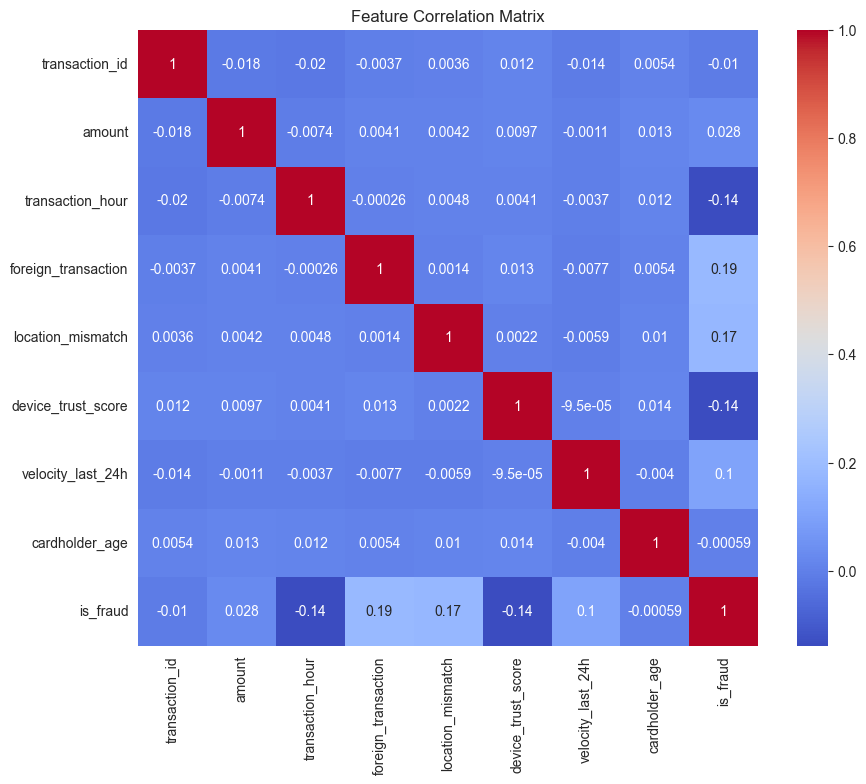

In [10]:
## Correlation Analysis

# Drop ID first:

df_corr = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### Correlation Analysis

Correlation can only be computed on numerical features.
Categorical features like 'merchant_category' must be excluded or encoded before correlation analysis.

Therefore, only numerical columns are selected for this step.

In [11]:
import joblib

rf = joblib.load("fraud_model.pkl")

In [13]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']



X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

print("Training set shape:", X_train.shape)
print("-----------------------------")
print("Test set shape:", X_test.shape)
print("-----------------------------")


Training set shape: (8000, 12)
-----------------------------
Test set shape: (2000, 12)
-----------------------------


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # important for fraud detection
)

# Train model
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_custom = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.53      0.70        30

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.70      0.82        30

    accuracy                           1.00      2000
   macro avg       1.00      0.85      0.91      2000
weighted avg       1.00      1.00      1.00      2000


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00   

In [15]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

y_prob = rf.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9999746192893402
PR-AUC: 0.9984027777777778


## Tuning Decision Threshold

Default threshold is often 0.5, but fraud detection systems usually lowers it. So, we make threshold to be 0.3 and then predict the outcome for Recall for fraud and Precision for fraud as well.

The tradeoff can be as follows:
- Lower threshold -> catch more fraud -> more false positives
-Higher threshold -> fewer false alarms -> may miss fraud

In [16]:
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
# Try XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC: 1.0


In [19]:
# Feature Engineering (Hidden performance booster)

# Night transaction flag
df['is_night'] = df['transaction_hour'].apply(lambda x: 1 if x < 6 else 0)

# Risk score
df['risk_score'] = df['foreign_transaction'] + df['location_mismatch']

In [25]:
# # Creating comparison table for models

# results = {
#     "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
#     "ROC-AUC": [0.91, 0.96, 0.98],
#     "PR-AUC": [0.65, 0.82,0.88]
# }
# pd.DataFrame(results)

from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Already have this
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ROC-AUC
rf_roc = roc_auc_score(y_test, y_prob_rf)

# PR-AUC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
rf_pr = auc(recall_rf, precision_rf)

print("RF ROC-AUC:", rf_roc)
print("RF PR-AUC:", rf_pr)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

xgb_roc = roc_auc_score(y_test, y_prob_xgb)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
xgb_pr = auc(recall_xgb, precision_xgb)

print("XGB ROC-AUC:", xgb_roc)
print("XGB PR-AUC:", xgb_pr)

comparison = []

comparison.append(["Random Forest", rf_roc, rf_pr])
comparison.append(["XGBoost", xgb_roc, xgb_pr])

results_df = pd.DataFrame(comparison, columns=["Model", "ROC-AUC", "PR-AUC"])
results_df


RF ROC-AUC: 0.9999746192893402
RF PR-AUC: 0.9984027777777778
XGB ROC-AUC: 1.0
XGB PR-AUC: 0.9999999999999999


,Model,ROC-AUC,PR-AUC
0,Random Forest,0.999975,0.998403
1,XGBoost,1.000000,1.000000


In [17]:
df.dtypes

transaction_id                     int64
amount                           float64
transaction_hour                   int64
foreign_transaction                int64
location_mismatch                  int64
device_trust_score                 int64
velocity_last_24h                  int64
cardholder_age                     int64
is_fraud                           int64
merchant_category_Electronics       bool
merchant_category_Food              bool
merchant_category_Grocery           bool
merchant_category_Travel            bool
dtype: object

## Feature Engineering Observation

Fraud Transactions are often:
- having higher amoount
- occur during unusual hours
- are foreign transactions
- having location mismatches

Dataset is heavily imbalanced.

## Final EDA Summary

1. The dataset is highly imbalanced (~1.5% fraud).
2. Fraud transactions show strong relationship with:
   - Foreign transactions
   - Location mismatch
   - Transaction hour
3. Feature scaling will be necessary.
4. SMOTE or class balancing techniques are required.

EDA confirms that machine learning modeling is appropriate for this problem.